Importing the Dependencies

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

Data Collection & Analysis

In [4]:
# loading the data from csv file to a Pandas DataFrame
parkinsons_data = pd.read_csv("../Datasets/data/parkinsons.csv")

In [5]:
# printing the first 5 rows of the dataframe
parkinsons_data.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [6]:
# number of rows and columns in the dataframe
parkinsons_data.shape

(4500, 24)

In [7]:
# getting more information about the dataset
parkinsons_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              4500 non-null   object 
 1   MDVP:Fo(Hz)       4500 non-null   float64
 2   MDVP:Fhi(Hz)      4500 non-null   float64
 3   MDVP:Flo(Hz)      4500 non-null   float64
 4   MDVP:Jitter(%)    4500 non-null   float64
 5   MDVP:Jitter(Abs)  4500 non-null   float64
 6   MDVP:RAP          4500 non-null   float64
 7   MDVP:PPQ          4500 non-null   float64
 8   Jitter:DDP        4500 non-null   float64
 9   MDVP:Shimmer      4500 non-null   float64
 10  MDVP:Shimmer(dB)  4500 non-null   float64
 11  Shimmer:APQ3      4500 non-null   float64
 12  Shimmer:APQ5      4500 non-null   float64
 13  MDVP:APQ          4500 non-null   float64
 14  Shimmer:DDA       4500 non-null   float64
 15  NHR               4500 non-null   float64
 16  HNR               4500 non-null   float64


In [8]:
# checking for missing values in each column
parkinsons_data.isnull().sum()

name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

In [9]:
# getting some statistical measures about the data
parkinsons_data.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,...,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,154.120913,198.920148,108.819876,0.006173,0.000043,0.003361,0.003540,0.009952,0.030660,0.290060,...,0.047591,0.026126,21.915129,0.758222,0.498781,0.719061,-5.697655,0.226257,2.377713,0.207076
std,45.099208,83.508820,43.149941,0.004012,0.000046,0.002474,0.002475,0.007168,0.018683,0.195145,...,0.030809,0.029294,4.442255,0.428208,0.104675,0.055696,1.102378,0.083952,0.379197,0.090129
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,115.046000,137.869250,72.490000,0.003340,0.000012,0.001610,0.001798,0.004897,0.016178,0.146000,...,0.023465,0.006110,18.932250,1.000000,0.419043,0.677974,-6.526489,0.167127,2.108052,0.138469
50%,147.623000,176.409000,94.719000,0.005030,0.000025,0.002670,0.002800,0.007970,0.025185,0.230000,...,0.038390,0.016315,21.963500,1.000000,0.504802,0.720917,-5.786559,0.223780,2.352084,0.193939
75%,189.317750,234.595000,134.655500,0.007763,0.000056,0.004280,0.004472,0.012680,0.040155,0.374250,...,0.063613,0.035162,24.900250,1.000000,0.585065,0.762278,-4.954768,0.281975,2.623098,0.261962
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [10]:
# distribution of target Variable
parkinsons_data['status'].value_counts()

status
1    3412
0    1088
Name: count, dtype: int64

1  --> Parkinson's Positive

0 --> Healthy


In [11]:
# grouping the data based on the target variable (mean of numeric features only)
numeric_cols = parkinsons_data.select_dtypes(include=[np.number]).columns
parkinsons_data.groupby('status')[numeric_cols].mean()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
status,,,,,,,,,,,,,,,,,,,,,
0,169.091509,210.014951,121.993122,0.005267,0.000029,0.002892,0.002973,0.008579,0.025089,0.232055,...,0.040402,0.021494,22.843018,0.0,0.473690,0.707856,-6.202986,0.192323,2.285128,0.166121
1,149.347171,195.382297,104.619263,0.006463,0.000048,0.003511,0.003721,0.010390,0.032437,0.308556,...,0.049883,0.027603,21.619249,1.0,0.506781,0.722634,-5.536517,0.237078,2.407236,0.220135


Data Pre-Processing

Separating the features & Target

In [12]:
X = parkinsons_data.drop(columns=['name','status'], axis=1)
Y = parkinsons_data['status']

In [13]:
print(X)

      MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0         119.992       157.302        74.997         0.00784   
1         122.400       148.650       113.819         0.00968   
2         116.682       131.111       111.555         0.01050   
3         116.676       137.871       111.366         0.00997   
4         116.014       141.781       110.655         0.01284   
...           ...           ...           ...             ...   
4495      221.907       329.148        75.307         0.00439   
4496      195.597       273.792       104.612         0.00962   
4497      136.916       141.204        92.535         0.00307   
4498       91.772       167.139        65.865         0.01394   
4499      227.301       304.594        95.647         0.00520   

      MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  \
0             0.000070   0.00370   0.00554     0.01109       0.04374   
1             0.000080   0.00465   0.00696     0.01394       0.06134   
2  

In [14]:
print(Y)

0       1
1       1
2       1
3       1
4       1
       ..
4495    1
4496    1
4497    1
4498    1
4499    0
Name: status, Length: 4500, dtype: int64


Splitting the data to training data & Test data

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [16]:
print(X.shape, X_train.shape, X_test.shape)

(4500, 22) (3600, 22) (900, 22)


Model Training

Support Vector Machine Model

In [17]:
model = svm.SVC(kernel='linear')

In [18]:
# training the SVM model with training data
model.fit(X_train, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Model Evaluation

Accuracy Score

In [19]:
# accuracy score on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)

In [20]:
print('Accuracy score of training data : ', training_data_accuracy)

Accuracy score of training data :  0.7538888888888889


In [21]:
# accuracy score on training data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)

In [22]:
print('Accuracy score of test data : ', test_data_accuracy)

Accuracy score of test data :  0.7755555555555556


Building a Predictive System

In [23]:
input_data = (197.07600,206.89600,192.05500,0.00289,0.00001,0.00166,0.00168,0.00498,0.01098,0.09700,0.00563,0.00680,0.00802,0.01689,0.00339,26.77500,0.422229,0.741367,-7.348300,0.177551,1.743867,0.085569)

# changing input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)


if (prediction[0] == 0):
  print("The Person does not have Parkinsons Disease")

else:
  print("The Person has Parkinsons")


[1]
The Person has Parkinsons


c:\Users\sahil\OneDrive\Desktop\CODE\Trail\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Saving the trained model

In [24]:
import pickle

In [25]:
filename = 'parkinsons_model.sav'
pickle.dump(model, open(filename, 'wb'))

In [26]:
# loading the saved model
loaded_model = pickle.load(open('parkinsons_model.sav', 'rb'))

In [27]:
for column in X.columns:
  print(column)

MDVP:Fo(Hz)
MDVP:Fhi(Hz)
MDVP:Flo(Hz)
MDVP:Jitter(%)
MDVP:Jitter(Abs)
MDVP:RAP
MDVP:PPQ
Jitter:DDP
MDVP:Shimmer
MDVP:Shimmer(dB)
Shimmer:APQ3
Shimmer:APQ5
MDVP:APQ
Shimmer:DDA
NHR
HNR
RPDE
DFA
spread1
spread2
D2
PPE


# Model Performance Visualization & Analysis
This section includes comprehensive visualizations for training accuracy, confusion matrix, ROC curve, and feature importance.

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
import os

# Create output directory for graphs
os.makedirs('../ML/graphs', exist_ok=True)

# Calculate additional metrics
precision = precision_score(Y_test, X_test_prediction)
recall = recall_score(Y_test, X_test_prediction)
f1 = f1_score(Y_test, X_test_prediction)

print(f"Training Accuracy: {training_data_accuracy:.4f}")
print(f"Test Accuracy: {test_data_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Training Accuracy: 0.7539
Test Accuracy: 0.7756
Precision: 0.7756
Recall: 1.0000
F1 Score: 0.8736


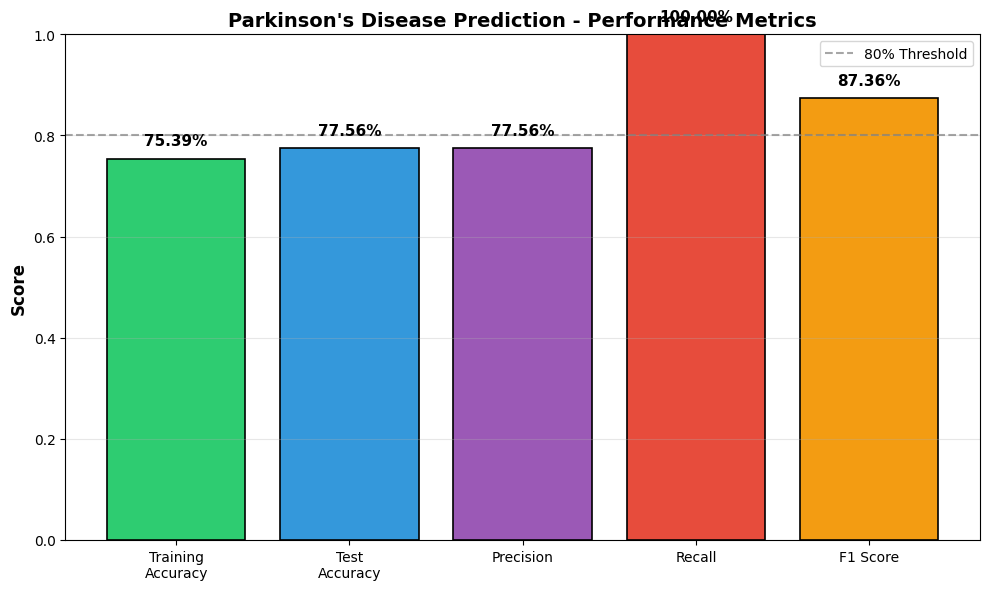

✅ Graph saved to: graphs/parkinsons_performance_metrics.png


In [29]:
# 1. Performance Metrics Bar Graph
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ['Training\nAccuracy', 'Test\nAccuracy', 'Precision', 'Recall', 'F1 Score']
values = [training_data_accuracy, test_data_accuracy, precision, recall, f1]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12']

bars = ax.bar(metrics, values, color=colors, edgecolor='black', linewidth=1.2)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title("Parkinson's Disease Prediction - Performance Metrics", fontsize=14, fontweight='bold')
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.7, label='80% Threshold')

# Add value labels on bars
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../ML/graphs/parkinsons_performance_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to: graphs/parkinsons_performance_metrics.png")

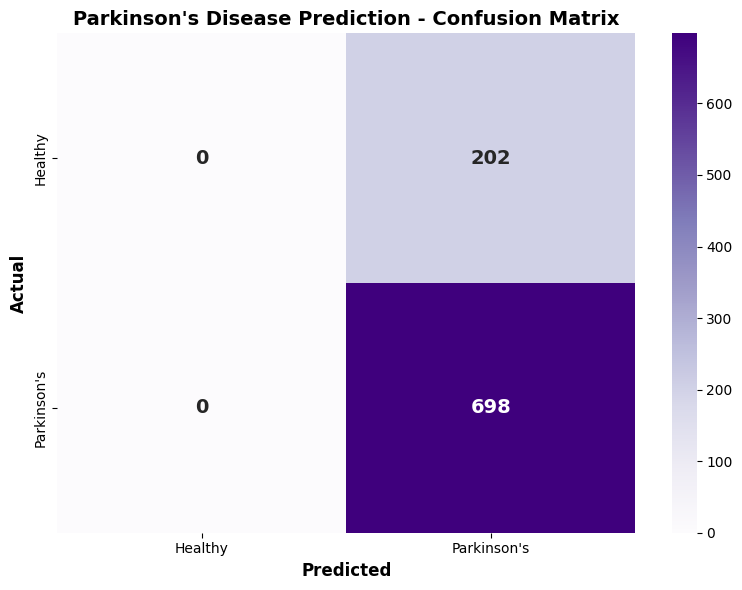

✅ Graph saved to: graphs/parkinsons_confusion_matrix.png


In [30]:
# 2. Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax, 
            xticklabels=['Healthy', "Parkinson's"],
            yticklabels=['Healthy', "Parkinson's"],
            annot_kws={'size': 14, 'fontweight': 'bold'})
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title("Parkinson's Disease Prediction - Confusion Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../ML/graphs/parkinsons_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to: graphs/parkinsons_confusion_matrix.png")

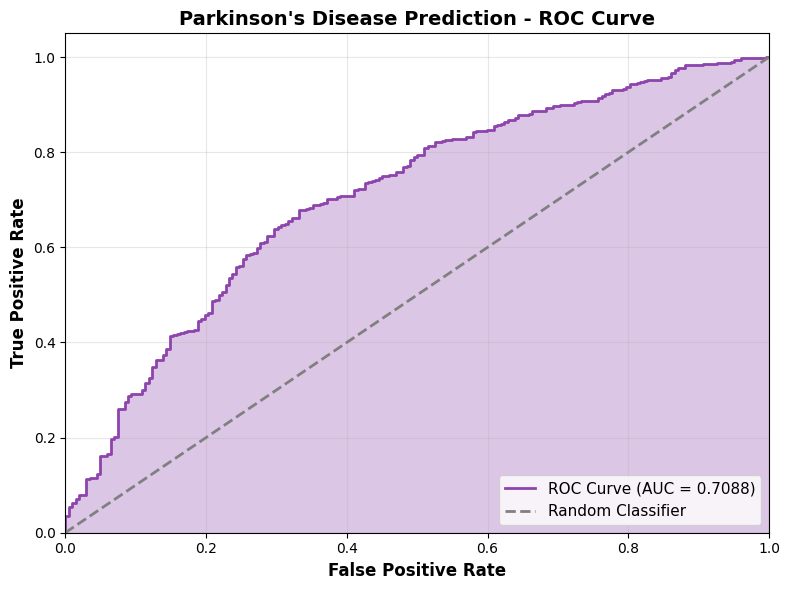

✅ Graph saved to: graphs/parkinsons_roc_curve.png


In [31]:
# 3. ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
# Get decision function scores for ROC curve
y_scores = model.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(Y_test, y_scores)
roc_auc = auc(fpr, tpr)

ax.plot(fpr, tpr, color='#8e44ad', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.3, color='#8e44ad')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title("Parkinson's Disease Prediction - ROC Curve", fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../ML/graphs/parkinsons_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to: graphs/parkinsons_roc_curve.png")

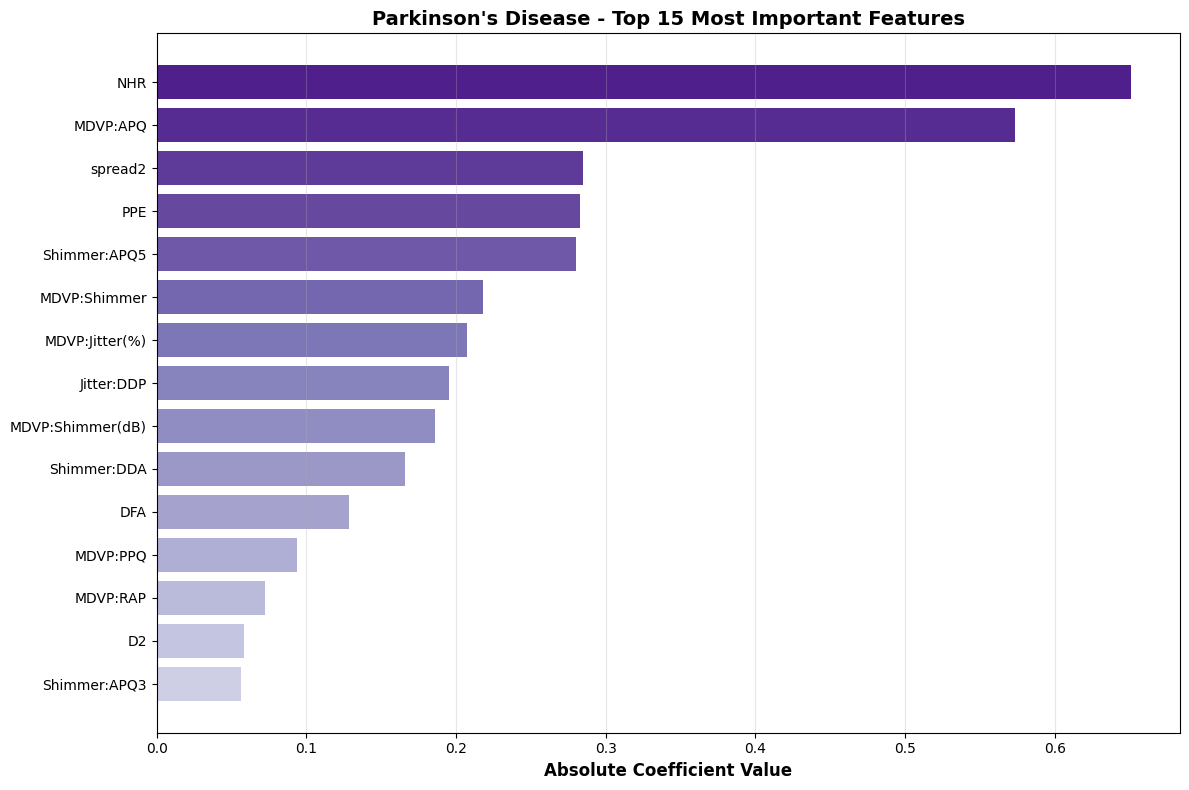

✅ Graph saved to: graphs/parkinsons_feature_importance.png


In [32]:
# 4. Top 10 Feature Importance (based on SVM coefficients)
fig, ax = plt.subplots(figsize=(12, 8))
feature_names = X.columns.tolist()
coefficients = model.coef_[0]
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(coefficients)
}).sort_values('Importance', ascending=True).tail(15)  # Top 15 features

colors = plt.cm.Purples(np.linspace(0.3, 0.9, len(importance_df)))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
ax.set_xlabel('Absolute Coefficient Value', fontsize=12, fontweight='bold')
ax.set_title("Parkinson's Disease - Top 15 Most Important Features", fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../ML/graphs/parkinsons_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to: graphs/parkinsons_feature_importance.png")

In [33]:
# 5. Download Parkinson's Graphs as ZIP
import zipfile
from pathlib import Path

def create_parkinsons_graphs_zip():
    """Create a downloadable ZIP file containing Parkinson's model graphs."""
    graphs_dir = Path('../ML/graphs')
    zip_path = graphs_dir / 'parkinsons_graphs.zip'
    
    if graphs_dir.exists():
        graph_files = [f for f in graphs_dir.glob('parkinsons_*.png')]
        
        if graph_files:
            with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
                for graph_file in graph_files:
                    zipf.write(graph_file, graph_file.name)
            
            print(f"📦 Created ZIP archive with {len(graph_files)} Parkinson's graphs:")
            for gf in sorted(graph_files):
                print(f"   ✓ {gf.name}")
            print(f"\n📥 Download from: {zip_path.absolute()}")
            return str(zip_path.absolute())
        else:
            print("⚠️ No Parkinson's graph files found. Run visualization cells first.")
    return None

create_parkinsons_graphs_zip()

📦 Created ZIP archive with 4 Parkinson's graphs:
   ✓ parkinsons_confusion_matrix.png
   ✓ parkinsons_feature_importance.png
   ✓ parkinsons_performance_metrics.png
   ✓ parkinsons_roc_curve.png

📥 Download from: c:\Users\sahil\OneDrive\Desktop\CODE\Trail\ML\..\ML\graphs\parkinsons_graphs.zip


'c:\\Users\\sahil\\OneDrive\\Desktop\\CODE\\Trail\\ML\\..\\ML\\graphs\\parkinsons_graphs.zip'